# Runoff Backend API Client Integration

This notebook interacts with your FastAPI backend directly for:
- Health check
- Latest model metadata from registry
- Best model name resolution
- Single and batch-like predictions via `/predict`
- Model metrics visualization (when available)

Expected backend URL: `http://localhost:8010`

## 1) Imports and Configuration

In [24]:
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = "http://localhost:8010"
API_KEY = "dev-key-12345"
TIMEOUT = 60

HEADERS = {
    "x-api-key": API_KEY,
    "Content-Type": "application/json",
}

train_result = None

print("Configured API client settings")
print(f"BASE_URL: {BASE_URL}")

Configured API client settings
BASE_URL: http://localhost:8010


In [25]:
# Auto-detect active backend URL by validating required OpenAPI routes
candidate_urls = [
    "http://localhost:8025",
    "http://localhost:8010",
    "http://localhost:8000",
]

required_paths = {"/health", "/metrics/latest", "/predict", "/train/auto"}
selected_url = None

for candidate in candidate_urls:
    try:
        health_resp = requests.get(f"{candidate}/health", timeout=3)
        if health_resp.status_code != 200:
            continue

        openapi_resp = requests.get(f"{candidate}/openapi.json", timeout=3)
        if openapi_resp.status_code != 200:
            continue

        spec = openapi_resp.json()
        available_paths = set((spec.get("paths") or {}).keys())
        if required_paths.issubset(available_paths):
            selected_url = candidate
            break
    except Exception:
        pass

if selected_url is not None:
    BASE_URL = selected_url
    print(f"Auto-detected backend: {BASE_URL}")
else:
    print("No compatible backend detected on ports 8010 or 8000. Using configured BASE_URL as-is.")
    print(f"Current BASE_URL: {BASE_URL}")

Auto-detected backend: http://localhost:8025


In [26]:
def show_active_backend():
    print(f"Using backend: {BASE_URL}")

show_active_backend()

Using backend: http://localhost:8025


## 2) Lightweight API Helpers

In [27]:
DEBUG_REQUEST_TARGET = True

def _raise_for_status_with_details(response):
    try:
        response.raise_for_status()
    except requests.HTTPError as exc:
        details = response.text
        print(f"HTTP {response.status_code} error body: {details}")
        raise exc


def api_get(path: str, params=None):
    url = f"{BASE_URL}{path}"
    if DEBUG_REQUEST_TARGET:
        show_active_backend()
        print(f"[GET] {url}")
    response = requests.get(url, headers=HEADERS, params=params, timeout=TIMEOUT)
    _raise_for_status_with_details(response)
    return response.json()


def api_post(path: str, payload, timeout=TIMEOUT):
    url = f"{BASE_URL}{path}"
    if DEBUG_REQUEST_TARGET:
        show_active_backend()
        print(f"[POST] {url}")
    response = requests.post(url, headers=HEADERS, json=payload, timeout=timeout)
    _raise_for_status_with_details(response)
    return response.json()


print("Helper functions ready")
print(f"Active BASE_URL: {BASE_URL}")

Helper functions ready
Active BASE_URL: http://localhost:8025


## 3) Health Check

In [28]:
health = api_get("/health")
print(json.dumps(health, indent=2, default=str))

Using backend: http://localhost:8025
[GET] http://localhost:8025/health
{
  "status": "ok"
}


## 4) Latest Model Metadata

In [29]:
latest_metrics = api_get("/metrics/latest")
print("Latest metrics payload:")
print(json.dumps(latest_metrics, indent=2, default=str))

best_model_info = latest_metrics.get("best_model", {}) if isinstance(latest_metrics, dict) else {}

if best_model_info:
    latest_df = pd.DataFrame([best_model_info])
    display(latest_df)
else:
    print("No model metadata available in registry yet.")

Using backend: http://localhost:8025
[GET] http://localhost:8025/metrics/latest
Latest metrics payload:
{
  "best_model": {
    "model_name": "xgboost",
    "rmse": 19666730.62552167,
    "mae": 11841923.0,
    "r2": 0.5536336898803711,
    "nse": 0.5536336213778277,
    "cv_score_rmse": 16730149.333333334,
    "best_params": {
      "subsample": 0.7,
      "n_estimators": 400,
      "max_depth": 5,
      "learning_rate": 0.01
    }
  }
}


,model_name,rmse,mae,r2,nse,cv_score_rmse,best_params
0,xgboost,1.966673e+07,11841923.0,0.553634,0.553634,1.673015e+07,"{'subsample': 0.7, 'n_estimators': 400, 'max_d..."


## 5) Get Best Model

In [37]:
best_model_name = None
artifact_path = None

if isinstance(best_model_info, dict) and best_model_info:
    best_model_name = best_model_info.get("model_name") or best_model_info.get("name")
    artifact_path = best_model_info.get("artifact_path") or best_model_info.get("model_path")

print("Resolved best model name:", best_model_name)
print("Resolved artifact path:", artifact_path)

if not artifact_path:
    print("⚠️ Model artifact path is missing in registry. Run /train/auto after adding model_training_backend.py and visualization.py at project root.")

Resolved best model name: xgboost
Resolved artifact path: None
⚠️ Model artifact path is missing in registry. Run /train/auto after adding model_training_backend.py and visualization.py at project root.


## 6) Single Prediction

In [40]:
# Feature names must match what the trained model expects
sample_features = {
    "rainfall": 12.5,
    "temperature": 18.3,
    "humidity": 70.0,
    "soil_moisture": 0.40,
    "evapotranspiration": 3.1,
    "p1": 1.2,
    "p2": 1.1,
    "p3": 1.0,
    "p4": 0.9,
}

# Try to use artifact_path from training result if available
effective_artifact_path = artifact_path or (train_result.get("artifact_path") if isinstance(train_result, dict) else None)

if not effective_artifact_path:
    print("No registered artifact path found. Skipping prediction.")
else:
    print(f"Using artifact path: {effective_artifact_path}")
    single_pred_payload = {"features": sample_features}
    single_result = api_post("/predict", single_pred_payload)
    print("Single prediction response:")
    print(json.dumps(single_result, indent=2, default=str))

Using artifact path: models/best_xgboost.json
Using backend: http://localhost:8025
[POST] http://localhost:8025/predict
Single prediction response:
{
  "prediction": 116804952.0,
  "model_name": "xgboost"
}


## 7) Batch-like Prediction (Loop over `/predict`)

In [41]:
batch_features = [
    {"rainfall": 12.5, "temperature": 18.3, "humidity": 70.0, "soil_moisture": 0.40, "evapotranspiration": 3.1, "p1": 1.2, "p2": 1.1, "p3": 1.0, "p4": 0.9},
    {"rainfall": 15.0, "temperature": 19.1, "humidity": 72.0, "soil_moisture": 0.45, "evapotranspiration": 3.4, "p1": 1.8, "p2": 1.5, "p3": 1.3, "p4": 1.1},
    {"rainfall": 8.1,  "temperature": 17.6, "humidity": 65.0, "soil_moisture": 0.33, "evapotranspiration": 2.7, "p1": 0.9, "p2": 0.8, "p3": 0.7, "p4": 0.6},
]

# Try to use artifact_path from training result if available
effective_artifact_path = artifact_path or (train_result.get("artifact_path") if isinstance(train_result, dict) else None)

if not effective_artifact_path:
    print("No registered artifact path found. Skipping batch-like prediction.")
else:
    batch_result = []
    for i, row in enumerate(batch_features):
        pred = api_post("/predict", {"features": row})
        batch_result.append(pred)
        print(f"Batch item {i+1}: {pred}")

    print("\nBatch-like prediction response:")
    print(json.dumps(batch_result, indent=2, default=str))

Using backend: http://localhost:8025
[POST] http://localhost:8025/predict
Batch item 1: {'prediction': 116804952.0, 'model_name': 'xgboost'}
Using backend: http://localhost:8025
[POST] http://localhost:8025/predict
Batch item 2: {'prediction': 113049376.0, 'model_name': 'xgboost'}
Using backend: http://localhost:8025
[POST] http://localhost:8025/predict
Batch item 3: {'prediction': 105584256.0, 'model_name': 'xgboost'}

Batch-like prediction response:
[
  {
    "prediction": 116804952.0,
    "model_name": "xgboost"
  },
  {
    "prediction": 113049376.0,
    "model_name": "xgboost"
  },
  {
    "prediction": 105584256.0,
    "model_name": "xgboost"
  }
]


## 8) Model Comparison and Visualization

,model_name,rmse,mae,r2,nse,cv_score_rmse,best_params
0,xgboost,1.966673e+07,1.184192e+07,0.553634,0.553634,1.673015e+07,"{'subsample': 0.7, 'n_estimators': 400, 'max_d..."
1,random_forest,1.992806e+07,1.162138e+07,0.541692,0.541692,1.725058e+07,"{'n_estimators': 300, 'min_samples_split': 10,..."


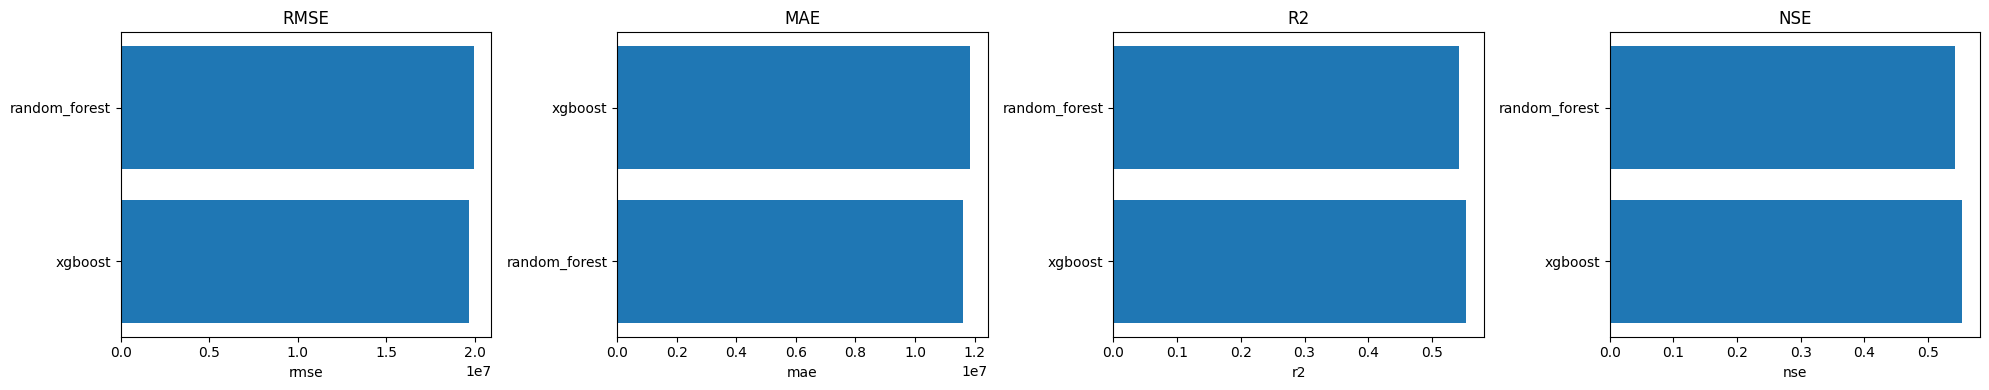

In [35]:
comparison_models = []

if "train_result" in globals() and isinstance(train_result, dict):
    if "all_models" in train_result and isinstance(train_result["all_models"], list):
        comparison_models = train_result["all_models"]

comparison_df = pd.DataFrame(comparison_models)

if comparison_df.empty:
    print("No comparison data available. Run /train/auto successfully first.")
else:
    display(comparison_df)

    metric_candidates = ["rmse", "mae", "r2", "nse"]
    available_metrics = [m for m in metric_candidates if m in comparison_df.columns]

    if "name" not in comparison_df.columns:
        if "model_name" in comparison_df.columns:
            comparison_df["name"] = comparison_df["model_name"]
        else:
            comparison_df["name"] = [f"model_{i}" for i in range(len(comparison_df))]

    if available_metrics:
        fig, axes = plt.subplots(1, len(available_metrics), figsize=(5 * len(available_metrics), 4))
        if len(available_metrics) == 1:
            axes = [axes]

        for ax, metric in zip(axes, available_metrics):
            asc = metric in ["rmse", "mae"]
            plot_df = comparison_df.sort_values(metric, ascending=asc)
            ax.barh(plot_df["name"], plot_df[metric])
            ax.set_title(metric.upper())
            ax.set_xlabel(metric)

        plt.tight_layout()
        plt.show()
    else:
        print("No standard metric columns found in training response")

## 9) Optional: Trigger Training from Notebook

Uncomment and run if you want to start training via API from this notebook.

In [34]:
train_payload = {
    "train_end_year": 2000,
    "test_start_year": 2006,
    "search_type": "randomized",
    "n_iter": 20
}

print("Training payload:")
print(json.dumps(train_payload, indent=2))

train_result = api_post("/train/auto", train_payload, timeout=900)
print("\nTraining response:")
print(json.dumps(train_result, indent=2, default=str))

Training payload:
{
  "train_end_year": 2000,
  "test_start_year": 2006,
  "search_type": "randomized",
  "n_iter": 20
}
Using backend: http://localhost:8025
[POST] http://localhost:8025/train/auto

Training response:
{
  "best_model": {
    "model_name": "xgboost",
    "rmse": 19666730.62552167,
    "mae": 11841923.0,
    "r2": 0.5536336898803711,
    "nse": 0.5536336213778277,
    "cv_score_rmse": 16730149.333333334,
    "best_params": {
      "subsample": 0.7,
      "n_estimators": 400,
      "max_depth": 5,
      "learning_rate": 0.01
    }
  },
  "all_models": [
    {
      "model_name": "xgboost",
      "rmse": 19666730.62552167,
      "mae": 11841923.0,
      "r2": 0.5536336898803711,
      "nse": 0.5536336213778277,
      "cv_score_rmse": 16730149.333333334,
      "best_params": {
        "subsample": 0.7,
        "n_estimators": 400,
        "max_depth": 5,
        "learning_rate": 0.01
      }
    },
    {
      "model_name": "random_forest",
      "rmse": 19928056.88170668,


## 10) Quick Endpoint Smoke Test

In [42]:
results = {}

checks = {
    "health": lambda: api_get("/health"),
    "metrics_latest": lambda: api_get("/metrics/latest"),
}

if artifact_path:
    checks["predict"] = lambda: api_post(
        "/predict",
        {
            "features": {
                "rainfall": 10.0,
                "temperature": 18.0,
                "humidity": 70.0,
                "soil_moisture": 0.4,
                "evapotranspiration": 3.0,
                "p1": 1.0,
                "p2": 1.0,
                "p3": 1.0,
            }
        },
    )
else:
    results["predict"] = "skipped: no artifact_path in registry"

for name, fn in checks.items():
    try:
        fn()
        results[name] = "ok"
    except Exception as exc:
        results[name] = f"failed: {exc}"

print("Smoke test summary:")
print(json.dumps(results, indent=2))

Using backend: http://localhost:8025
[GET] http://localhost:8025/health
Using backend: http://localhost:8025
[GET] http://localhost:8025/metrics/latest
Smoke test summary:
{
  "predict": "skipped: no artifact_path in registry",
  "health": "ok",
  "metrics_latest": "ok"
}
